In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/mnt/c/Users/heman/Downloads/e88186124ec611f1/dataset/train.csv")
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [4]:
df.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


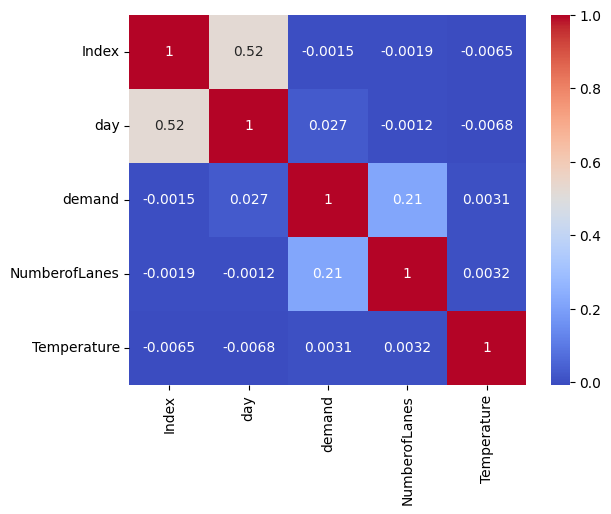

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [6]:
df['RoadType'].unique()

array([nan, 'Residential', 'Street', 'Highway'], dtype=object)

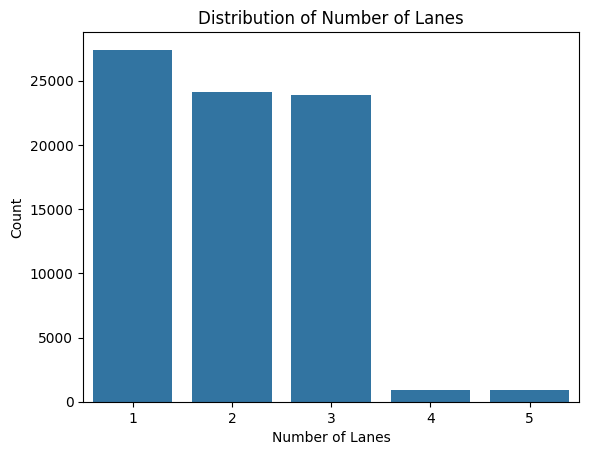

In [7]:
sns.countplot(x = 'NumberofLanes', data = df)
plt.title('Distribution of Number of Lanes')
plt.xlabel('Number of Lanes')
plt.ylabel('Count')
plt.show()

In [8]:
x = df.drop(['Index', 'demand'], axis = 1)
y = df['demand']

In [9]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 6)

In [11]:
def feature_engineering(df):
    df_copy = pd.DataFrame(df).copy()
    if 'timestamp' in df_copy.columns:
        time_split = df_copy['timestamp'].astype(str).str.split(':')
        df_copy['hour'] = time_split.str[0].astype(int)
        df_copy['minute'] = time_split.str[1].astype(int)
        df_copy.drop(columns=['timestamp'], inplace=True)
    if 'Temperature' in df_copy.columns:
        df_copy['Temp_Category'] = pd.cut(df_copy['Temperature'], bins=[0, 15, 30, 45], labels=['cold', 'mild', 'hot'])
        df_copy.drop(columns=['Temperature'], inplace=True)
    if 'geohash' in df_copy.columns:
        df_copy['location'] = df_copy['geohash'].astype(str).str[:5]
        df_copy.drop(columns=['geohash'], inplace=True)
    return df_copy

In [12]:
class feat_eng(BaseEstimator, TransformerMixin):
    def __init__(self, group_col, value_col, target_col_name):
        self.group_col = group_col
        self.value_col = value_col
        self.target_col_name = target_col_name
        self.means_ = {}

    def fit(self, X, y=None):
        df = pd.DataFrame(X)
        self.means_ = df.groupby(self.group_col)[self.value_col].mean().to_dict()
        self.global_mean_ = df[self.value_col].mean()
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()
        df[self.target_col_name] = df[self.group_col].map(self.means_).fillna(self.global_mean_)
        return df

In [13]:
nums = ['day', 'hour', 'minute', 'NumberofLanes', 'number_of_lanes_by_road']
cats = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'Temp_Category', 'location']

In [14]:
numeric_pipeline = Pipeline([('impute', SimpleImputer(strategy = 'median')), ('scale', RobustScaler())])
categorical_pipeline = Pipeline([('impute', SimpleImputer(strategy = 'most_frequent')), ('encode', OneHotEncoder(handle_unknown = 'ignore'))])

In [15]:
preprocessor = ColumnTransformer([('num', numeric_pipeline, nums), ('cat', categorical_pipeline, cats)])

In [16]:
features = FunctionTransformer(feature_engineering, validate = False)

In [17]:
feature_pipeline = Pipeline([('feat1', feat_eng(group_col = 'RoadType', value_col = 'NumberofLanes', target_col_name = 'number_of_lanes_by_road')), ('feat2', features)])

In [18]:
model_pipeline = Pipeline([('feat', feature_pipeline), ('pre', preprocessor), ('model', RandomForestRegressor(n_estimators = 200, random_state = 6))])

In [20]:
model_pipeline.fit(x_train, y_train)

,steps,"[('feat', ...), ('pre', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('feat1', ...), ('feat2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,group_col,'RoadType'
,value_col,'NumberofLanes'
,target_col_name,'number_of_lanes_by_road'


In [21]:
y_pred = model_pipeline.predict(x_test)

In [22]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 0.046530126923789224
Mean Squared Error: 0.004970138964149909
R^2 Score: 0.7574348565877398
